# Projeto 1 (v2) — Modelo de preço justo em RAM

Este notebook substitui o **score de custo-benefício feito à mão** do v1 por um
**modelo de preço aprendido dos dados**. A partir das specs que já extraímos no
notebook de NLP (geração, capacidade, frequência, latência) e do fabricante, o
modelo estima quanto uma peça **deveria** custar e devolve uma **faixa de preço**
com garantia de cobertura (*conformal prediction*).

Em cima disso construímos três coisas:

1. **Detector de oferta** — comparando o preço real com a faixa prevista, dá pra
   dizer se um produto está *barato*, *justo* ou *caro*.
2. **Explicação (SHAP)** — o que puxa o preço pra cima ou pra baixo, no geral e
   produto a produto.
3. **Comparação com um modelo fundacional (TabICL)** — o transformer tabular que
   prevê *sem tuning* e dá incerteza de graça, contra a RandomForest + conformal.

Começamos por **RAM** (mais dados, é de onde o projeto partiu). A estrutura é
feita pra generalizar: pra rodar em outra categoria, basta acrescentar uma entrada
em `FEATURES` e trocar `CATEGORIA`. Ao final, salvamos os artefatos que o
**aplicativo (Streamlit)** vai carregar.

> Cobertura alvo de 90% → `alpha = 0.10`.

In [37]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import pathlib

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

import shap

RANDOM_STATE = 42
alpha = 0.10 # cobertura alvo de 90%
CATEGORIA = "ram"  # (cpu, gpu, ...)

## Dataset

Em vez de um único snapshot, juntamos o `kabum_todas_pecas_<data>.csv` de **cada**
pasta de coleta em `00_Dados` num único DataFrame (várias datas, todas as
categorias). Isso dá mais linhas de treino, ao custo de ainda não termos as specs
extraídas via NLP (`ram_geracao`, `ram_gb`, `ram_mhz`, `ram_cl`) para as coletas
mais recentes — só a pasta `2026-05-16` tem os `_features.csv`. Por enquanto
seguimos só com o que está disponível em todas as coletas; a extração de specs
fica para um passo posterior.

In [38]:
import os

# 00_Dados/ mora na raiz do repositorio (dois niveis acima deste notebook).
# Defina a variavel de ambiente KABUM_DATA_ROOT para apontar para outro lugar
# sem editar o codigo.
DATA_ROOT = os.environ.get("KABUM_DATA_ROOT", "../../00_Dados")
MODEL_DIR = "modelos"

# Colunas de specs geradas pelo notebook de feature engineering, por categoria
# (ajuste os nomes se você mudou algo na extração)
FEATURES_COLS = {
    "ram":       ["ram_geracao", "ram_gb", "ram_mhz", "ram_cl", "ram_notebook"],
    "cpu":       ["cpu_marca", "cpu_socket", "cpu_serie", "cpu_tdp_w", "cpu_ddr_suportado", "cpu_com_cooler"],
    "gpu":       ["gpu_marca_chip", "gpu_modelo", "gpu_vram_gb", "gpu_tdp_w"],
    "ssd":       ["ssd_interface", "ssd_geracao_pcie", "ssd_capacidade_gb", "ssd_notebook"],
    "fonte":     ["fonte_wattagem", "fonte_certificacao", "fonte_modular", "fonte_atx3"],
    "placa_mae": ["mobo_socket", "mobo_chipset", "mobo_ddr", "mobo_form_factor", "mobo_slots_m2", "mobo_max_ram_gb"],
}

arquivos = sorted(glob.glob(f"{DATA_ROOT}/*/kabum_todas_pecas_*.csv"))
assert arquivos, f"Nenhum kabum_todas_pecas_*.csv encontrado em {DATA_ROOT}"

print(f"{len(arquivos)} arquivos encontrados:")

dfs_datas = []
for arquivo in arquivos:
    pasta = pathlib.Path(arquivo).parent
    data_coleta = pasta.name          # supõe que a pasta se chama exatamente a data, ex. "2026-06-26"

    base = pd.read_csv(arquivo)
    print(f" - {arquivo}  ({len(base)} linhas antes do merge)")

    for cat, cols in FEATURES_COLS.items():
        arq_feat = pasta / f"kabum_{cat}_{data_coleta}_features.csv"
        if not arq_feat.exists():
            print(f"     [aviso] {arq_feat.name} não encontrado — specs de '{cat}' ficarão NaN nesta data")
            continue

        feat = pd.read_csv(arq_feat, usecols=lambda c: c == "id" or c in cols)
        if "id" not in feat.columns:
            print(f"     [aviso] '{arq_feat.name}' não tem coluna 'id' — pulei o merge")
            continue

        antes = base.shape[1]
        base = base.merge(feat, on="id", how="left")
        print(f"     merge '{cat}': +{base.shape[1] - antes} colunas, "
              f"{base[cols[0]].notna().sum() if cols[0] in base.columns else 0} linhas casadas em '{cols[0]}'")

    dfs_datas.append(base)

df = pd.concat(dfs_datas, ignore_index=True)
print("\nshape combinado:", df.shape)
#df.head()

7 arquivos encontrados:
 - C:\Users\julia\OneDrive\Área de Trabalho\Projetos\Perspectivas de Dados\perspectiva_dados_projeto2\00_Dados\2026-05-16\kabum_todas_pecas_2026-05-16.csv  (4636 linhas antes do merge)
     merge 'ram': +5 colunas, 1150 linhas casadas em 'ram_geracao'
     merge 'cpu': +6 colunas, 480 linhas casadas em 'cpu_marca'
     merge 'gpu': +4 colunas, 579 linhas casadas em 'gpu_marca_chip'
     merge 'ssd': +4 colunas, 715 linhas casadas em 'ssd_interface'
     merge 'fonte': +4 colunas, 588 linhas casadas em 'fonte_wattagem'
     merge 'placa_mae': +6 colunas, 494 linhas casadas em 'mobo_socket'
 - C:\Users\julia\OneDrive\Área de Trabalho\Projetos\Perspectivas de Dados\perspectiva_dados_projeto2\00_Dados\2026-06-26\kabum_todas_pecas_2026-06-26.csv  (4577 linhas antes do merge)
     merge 'ram': +5 colunas, 1099 linhas casadas em 'ram_geracao'
     merge 'cpu': +6 colunas, 513 linhas casadas em 'cpu_marca'
     merge 'gpu': +4 colunas, 397 linhas casadas em 'gpu_marca_c

In [8]:
df.head()

,data_coleta,categoria_key,id,nome,preco_original,preco_atual,preco_pix,desconto_pct,avaliacao,num_avaliacoes,...,fonte_wattagem,fonte_certificacao,fonte_modular,fonte_atx3,mobo_socket,mobo_chipset,mobo_ddr,mobo_form_factor,mobo_slots_m2,mobo_max_ram_gb
0,2026-05-16,cpu,520368,"Processador AMD Ryzen 5 5600GT, 3.6 GHz, (4.6G...",1294.09,1294.09,1099.98,15,5,851,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-05-16,cpu,320799,"Processador AMD Ryzen 5 5500, 3.6GHz (4.2GHz M...",1339.09,1339.09,1138.23,15,5,860,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2026-05-16,cpu,320797,"Processador AMD Ryzen 7 5700X, 3.4GHz (4.6GHz ...",2491.04,2491.04,2117.38,15,5,887,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2026-05-16,cpu,426262,"Processador AMD Ryzen 7 7800X3D, 5.0GHz Max Tu...",4235.28,4235.28,3599.99,15,5,240,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2026-05-16,cpu,662405,"Processador AMD Ryzen 7 9800X3D, Cache 8MB, 8 ...",4352.93,4352.93,3699.99,15,5,203,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Conferindo a junção

Antes de seguir: quantas datas entraram, quantos produtos por categoria, e se há
duplicatas (mesmo `id` repetido **dentro da mesma data** seria um sinal de
problema; o mesmo produto aparecendo em datas diferentes é esperado).

In [39]:
print("datas de coleta:", sorted(df["data_coleta"].unique()))
print()
print(df["categoria_key"].value_counts())
print()
dups_mesma_data = df.duplicated(subset=["id", "data_coleta"]).sum()
print("duplicatas (mesmo id na mesma data):", dups_mesma_data)
print()
print("valores ausentes por coluna:")
print(df.isna().sum())

datas de coleta: ['2026-05-16', '2026-06-26', '2026-06-28', '2026-06-30', '2026-07-01', '2026-07-02', '2026-07-06']

categoria_key
ram          8716
placa_mae    6187
ssd          6157
fonte        4217
cpu          3760
gpu          3599
Name: count, dtype: int64

duplicatas (mesmo id na mesma data): 855

valores ausentes por coluna:
data_coleta               0
categoria_key             0
id                        0
nome                      0
preco_original            0
preco_atual               0
preco_pix                 0
desconto_pct              0
avaliacao                 0
num_avaliacoes            0
disponivel                0
fabricante                0
categoria                 0
garantia                  0
frete_gratis              0
url                       0
ram_geracao           24644
ram_gb                23968
ram_mhz               26436
ram_cl                30402
ram_notebook          23920
cpu_socket            29573
cpu_tdp_w             32278
cpu_com_cooler     

## Configuração das features por categoria

Definimos, por categoria, quais colunas são **numéricas** e quais são
**categóricas**. O alvo é sempre `preco_pix`. Para RAM usamos as specs técnicas
(capacidade, frequência, latência), a geração e o fabricante — deliberadamente
**não** incluímos `avaliacao`/`num_avaliacoes` aqui: queremos um preço justo em
função do *que a peça é*, não da popularidade dela.

Se alguma coluna configurada não existir no CSV, ela é ignorada com um aviso — o
que facilita reaproveitar essa célula em outras categorias.

In [40]:
FEATURES = {
    "ram": {
        "num": ["ram_gb", "ram_mhz", "ram_cl"],
        "cat": ["ram_geracao", "fabricante"],
    },
    # Modelos para as próximas categorias (ajuste os nomes às suas colunas):
    "cpu":       {"num": ["cpu_tdp_w"],            "cat": ["cpu_socket", "cpu_marca", "cpu_ddr_suportado"]},
    "gpu":       {"num": ["gpu_vram_gb", "gpu_tdp_w"], "cat": ["fabricante"]},
    "ssd":       {"num": ["ssd_capacidade_gb"],    "cat": ["ssd_interface", "fabricante"]},
    "fonte":     {"num": ["fonte_wattagem"],       "cat": ["fonte_modular", "fabricante"]},
    "placa_mae": {"num": ["mobo_slots_m2"],        "cat": ["mobo_socket", "mobo_ddr", "mobo_form_factor"]},
}

ALVO = "preco_pix"
cfg = FEATURES[CATEGORIA]

# mantém só as colunas que realmente existem no CSV
num = [c for c in cfg["num"] if c in df.columns]
cat = [c for c in cfg["cat"] if c in df.columns]
faltando = set(cfg["num"] + cfg["cat"]) - set(num + cat)
if faltando:
    print("AVISO: colunas configuradas ausentes no CSV, serão ignoradas:", faltando)

print("numéricas:  ", num)
print("categóricas:", cat)

numéricas:   ['ram_gb', 'ram_mhz', 'ram_cl']
categóricas: ['ram_geracao', 'fabricante']


### Limpeza mínima

Removemos produtos sem preço válido e duplicatas óbvias. Um filtro de preço
opcional descarta valores absurdos que atrapalham o modelo (acessórios com preço
de brinde, erros de cadastro). Ajuste `PRECO_MIN`/`PRECO_MAX` se quiser.

In [41]:
PRECO_MIN, PRECO_MAX = 1, None   # None = sem teto

d = df[df["categoria_key"] == CATEGORIA].copy()
d = d.dropna(subset=[ALVO])
d = d[d[ALVO] >= PRECO_MIN]
if PRECO_MAX is not None:
    d = d[d[ALVO] <= PRECO_MAX]
d = d.drop_duplicates(subset=["nome"]) if "nome" in d.columns else d

# Filtro de sanidade: MHz acima de 9000 é fisicamente impossível pra RAM hoje
# (provavelmente erro de digitação no nome do produto no site de origem)
if "ram_mhz" in d.columns:
    n_antes = d["ram_mhz"].notna().sum()
    d.loc[d["ram_mhz"] > 9000, "ram_mhz"] = np.nan
    n_removidos = n_antes - d["ram_mhz"].notna().sum()
    if n_removidos:
        print(f"[aviso] {n_removidos} valor(es) de ram_mhz > 9000 zerados (provável erro de digitação na fonte)")

X = d[num + cat].copy()
y = d[ALVO].to_numpy()
print(f"{len(d)} produtos após limpeza")
d[[ALVO] + num + cat].describe(include="all").T

[aviso] 2 valor(es) de ram_mhz > 9000 zerados (provável erro de digitação na fonte)
1435 produtos após limpeza


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
preco_pix,1435.0,NaN,NaN,NaN,1328.482857,1772.300897,23.74,425.36,819.9,1499.0,18450.0
ram_gb,1425.0,NaN,NaN,NaN,15.022456,16.282342,1.0,8.0,8.0,16.0,256.0
ram_mhz,1077.0,NaN,NaN,NaN,3137.724234,1402.729853,200.0,2133.0,3200.0,3200.0,7000.0
ram_cl,394.0,NaN,NaN,NaN,25.5,11.95608,6.0,16.0,20.0,39.5,48.0
ram_geracao,1334,8,Ddr4,447,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fabricante,1435,87,Outros,500,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Separando treino, calibração e teste

Mesma divisão dos notebooks da disciplina: o **treino** ajusta os modelos, a
**calibração** define o quantil que garante a cobertura, e o **teste** avalia as
faixas no final. 60% / 20% / 20%.

In [42]:
X_treino_cal, X_teste, y_treino_cal, y_teste = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)
X_treino, X_cal, y_treino, y_cal = train_test_split(
    X_treino_cal, y_treino_cal, test_size=0.25, random_state=RANDOM_STATE
)
print("treino:    ", X_treino.shape)
print("calibração:", X_cal.shape)
print("teste:     ", X_teste.shape)

treino:     (861, 5)
calibração: (287, 5)
teste:      (287, 5)


## Pré-processamento

As specs têm **valores faltantes** (ex.: a latência CL raramente aparece no nome).
A RandomForest não aceita `NaN`, então:

- **numéricas** → imputação pela mediana;
- **categóricas** → valor faltante vira a categoria `"desconhecido"`, depois
  *one-hot*. `min_frequency=10` agrupa fabricantes raros em `infrequent`, evitando
  centenas de colunas.

Empacotar isso num `ColumnTransformer` faz o pré-processamento virar **um objeto
só**, salvável com `joblib` — o app aplica exatamente a mesma transformação a um
produto novo.

In [43]:
preproc = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), num),
    ("cat", Pipeline([
        ("imp", SimpleImputer(strategy="constant", fill_value="desconhecido")),
        ("oh",  OneHotEncoder(handle_unknown="ignore", min_frequency=10,
                              sparse_output=False)),
    ]), cat),
])

Xtr = preproc.fit_transform(X_treino)
feat_nomes = preproc.get_feature_names_out()

# DataFrames com nomes de coluna — o SHAP usa esses nomes nos gráficos
Xtr = pd.DataFrame(Xtr, columns=feat_nomes, index=X_treino.index)
Xca = pd.DataFrame(preproc.transform(X_cal),   columns=feat_nomes, index=X_cal.index)
Xte = pd.DataFrame(preproc.transform(X_teste), columns=feat_nomes, index=X_teste.index)

print(f"{Xtr.shape[1]} features após one-hot:")
print(list(feat_nomes))

22 features após one-hot:
['num__ram_gb', 'num__ram_mhz', 'num__ram_cl', 'cat__ram_geracao_DDR3', 'cat__ram_geracao_DDR4', 'cat__ram_geracao_DDR5', 'cat__ram_geracao_Ddr3', 'cat__ram_geracao_Ddr4', 'cat__ram_geracao_Ddr5', 'cat__ram_geracao_desconhecido', 'cat__ram_geracao_infrequent_sklearn', 'cat__fabricante_Adata', 'cat__fabricante_Corsair', 'cat__fabricante_Crucial', 'cat__fabricante_KEEPDATA', 'cat__fabricante_Kingston', 'cat__fabricante_MACROVIP', 'cat__fabricante_Outros', 'cat__fabricante_Patriot', 'cat__fabricante_Rise Mode', 'cat__fabricante_XPG', 'cat__fabricante_infrequent_sklearn']


## Modelo de preço justo + conformal normalizado

Dois modelos de RandomForest:

1. `modelo_media` prevê o preço.
2. `modelo_variancia` é treinado nos **resíduos²** do primeiro (no próprio treino)
   para prever *o tamanho do erro* em cada ponto.

Com isso fazemos o **conformal normalizado**: na calibração medimos o score
`|y − previsão| / escala`, com `escala = sqrt(variância prevista)`; o corte `q` é
um quantil desses scores (com correção de amostra finita). No teste, a faixa fica
`previsão ± q × escala` — **larga para peças difíceis de precificar, estreita para
as fáceis**. Calculamos também o conformal *comum* (largura fixa) só para comparar.

In [44]:
modelo_media = RandomForestRegressor(
    n_estimators=300, min_samples_leaf=5, n_jobs=-1, random_state=RANDOM_STATE
)
modelo_media.fit(Xtr, y_treino)

# modelo de variância nos resíduos do próprio treino
residuos = y_treino - modelo_media.predict(Xtr)
modelo_variancia = RandomForestRegressor(
    n_estimators=300, min_samples_leaf=5, n_jobs=-1, random_state=RANDOM_STATE
)
modelo_variancia.fit(Xtr, residuos ** 2)

pred_teste = modelo_media.predict(Xte)
print(f"MAE teste: R$ {mean_absolute_error(y_teste, pred_teste):.2f}")
print(f"R²  teste: {r2_score(y_teste, pred_teste):.3f}")

MAE teste: R$ 251.98
R²  teste: 0.915


In [45]:
def quantil_conformal(scores, alpha):
    n = len(scores)
    nivel = np.ceil((n + 1) * (1 - alpha)) / n
    return np.quantile(scores, nivel, method="higher")

# --- conformal comum (largura fixa) ---
erros_cal = np.abs(y_cal - modelo_media.predict(Xca))
q_comum = quantil_conformal(erros_cal, alpha)
baixo_comum = pred_teste - q_comum
alto_comum  = pred_teste + q_comum

# --- conformal normalizado (largura adaptativa) ---
escala_cal = np.sqrt(np.maximum(modelo_variancia.predict(Xca), 1e-6))
scores_norm = np.abs(y_cal - modelo_media.predict(Xca)) / escala_cal
q_norm = quantil_conformal(scores_norm, alpha)

escala_teste = np.sqrt(np.maximum(modelo_variancia.predict(Xte), 1e-6))
baixo_norm = pred_teste - q_norm * escala_teste
alto_norm  = pred_teste + q_norm * escala_teste

def resumo(nome, lo, hi):
    return {
        "metodo": nome,
        "cobertura": ((y_teste >= lo) & (y_teste <= hi)).mean(),
        "largura_media": np.mean(hi - lo),
    }

comparacao = pd.DataFrame([
    resumo("conformal comum", baixo_comum, alto_comum),
    resumo("conformal normalizado", baixo_norm, alto_norm),
])
comparacao

,metodo,cobertura,largura_media
0,conformal comum,0.916376,1347.699386
1,conformal normalizado,0.926829,1306.672230


### Visualizando as faixas

Ordenando os produtos de teste pelo preço previsto, dá pra ver a faixa normalizada
apertar e alargar conforme a peça — algo que a faixa de largura fixa não faz.

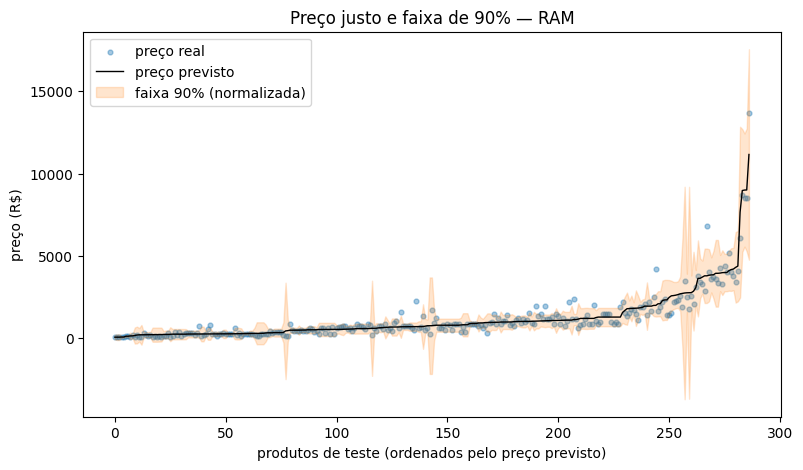

In [46]:
ordem = np.argsort(pred_teste)
xx = np.arange(len(pred_teste))

plt.figure(figsize=(9, 5))
plt.scatter(xx, y_teste[ordem], s=12, alpha=0.4, label="preço real")
plt.plot(xx, pred_teste[ordem], color="black", linewidth=1, label="preço previsto")
plt.fill_between(xx, baixo_norm[ordem], alto_norm[ordem], alpha=0.20,
                 color="tab:orange", label="faixa 90% (normalizada)")
plt.xlabel("produtos de teste (ordenados pelo preço previsto)")
plt.ylabel("preço (R$)")
plt.title(f"Preço justo e faixa de 90% — {CATEGORIA.upper()}")
plt.legend()
plt.show()

## Detector de oferta

A regra é direta: comparado com a faixa prevista, um produto cujo preço real está

- **abaixo** do piso da faixa → `oferta` (bom negócio),
- **acima** do teto → `caro`,
- **dentro** → `justo`.

`desvio_pct` mede o quanto o preço real está distante do preço justo previsto
(negativo = mais barato que o previsto). É esse número que vai virar o *ranking* do
recomendador no v2, no lugar do score à mão.

In [47]:
def classificar(preco_real, pred, lo, hi):
    if preco_real < lo:  status = "oferta"
    elif preco_real > hi: status = "caro"
    else:                 status = "justo"
    return status

res_teste = X_teste.copy()
if "nome" in d.columns:
    res_teste.insert(0, "nome", d.loc[X_teste.index, "nome"])
res_teste["preco_real"]  = y_teste
res_teste["preco_justo"] = pred_teste.round(2)
res_teste["faixa_baixo"] = baixo_norm.round(2)
res_teste["faixa_alto"]  = alto_norm.round(2)
res_teste["desvio_pct"]  = ((y_teste - pred_teste) / pred_teste * 100).round(1)
res_teste["status"] = [classificar(r, p, lo, hi)
                       for r, p, lo, hi in zip(y_teste, pred_teste, baixo_norm, alto_norm)]

print(res_teste["status"].value_counts())
# melhores ofertas (mais abaixo do preço justo)
cols = [c for c in ["nome", "preco_real", "preco_justo", "faixa_baixo", "faixa_alto", "desvio_pct", "status"] if c in res_teste.columns]
res_teste.sort_values("desvio_pct").head(10)[cols]

status
justo     266
caro       17
oferta      4
Name: count, dtype: int64


,nome,preco_real,preco_justo,faixa_baixo,faixa_alto,desvio_pct,status
4044,"Memória Notebook Nanya, 2GB, 1333MHz, DDR3 - P...",60.01,229.79,-188.02,647.59,-73.9,justo
4666,"Memória RAM XLinne, 8GB, DDR3, 1600MHz, CL11",187.85,609.36,-2279.66,3498.37,-69.2,justo
8292,Memoria 4gb Ddr3 1333 Cl 11 1.5v Desktop Udim...,66.95,215.14,-383.63,813.91,-68.9,justo
4668,Memória Ram Ddr3 8GB 1600mhz Cl11 1.5v 240pin ...,239.85,767.88,-2160.96,3696.72,-68.8,justo
3717,"Memória Bluecase SODIMM, 4GB, 1333MHz, DDR3, P...",82.49,250.21,-174.26,674.68,-67.0,justo
4400,"Memória Golden Memory, 4gb, 1600mhz, Ddr3, Cl1...",149.90,451.45,-2476.24,3379.14,-66.8,justo
4688,"Memoria Ram Perfil Baixo Ddr3 8GB, 1600mhz, PC...",159.90,467.75,-198.74,1134.24,-65.8,justo
4415,Memória Ram Ddr3 4gb 1600mhz PC3-12800u Smart,78.00,223.10,-204.98,651.19,-65.0,justo
31805,Memoria Ddr4 16gb 2666mhz Keepdata,347.03,959.96,403.66,1516.27,-63.8,oferta
4189,"Memoria Ddr3l 1,35v Para Notebook 4gb 1600mhz ...",103.99,223.10,-204.98,651.19,-53.4,justo


## SHAP — explicando o preço

Usamos o `TreeExplainer` (rápido para RandomForest). A propriedade central é a
**aditividade**: `previsão = base + Σ SHAP`. Explicamos o conjunto de teste.

In [48]:
explainer = shap.TreeExplainer(modelo_media)
shap_values = explainer(Xte)

i = 0
soma = shap_values.base_values[i] + shap_values.values[i].sum()
print(f"base + Σ SHAP = {soma:.2f}   |   modelo.predict = {pred_teste[i]:.2f}")

base + Σ SHAP = 283.98   |   modelo.predict = 283.98


**Importância global** — média dos `|SHAP|`: quais features mais mexem no preço
(magnitude, sem direção).

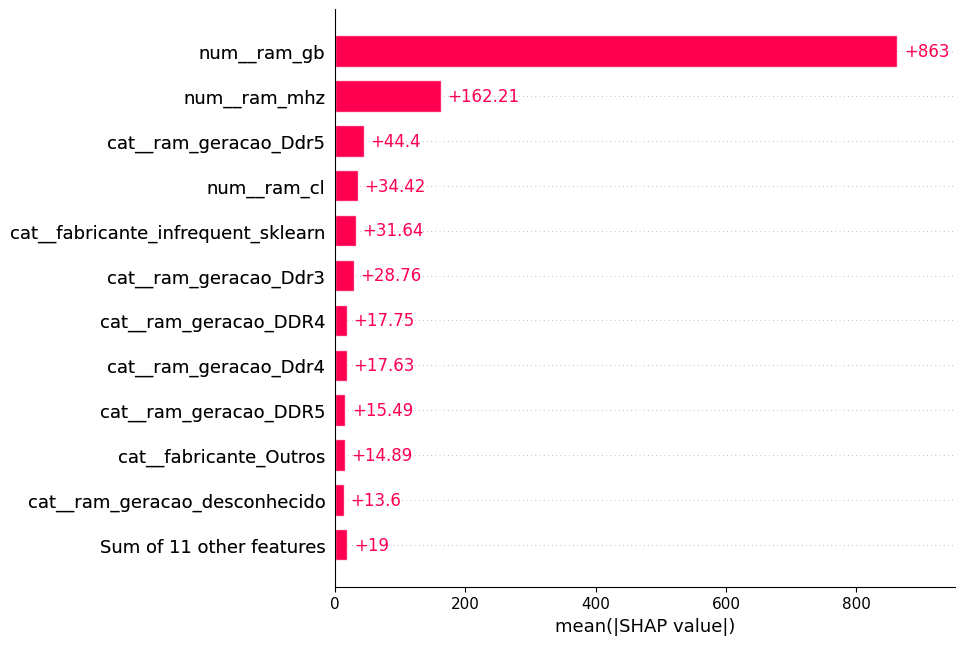

In [49]:
shap.plots.bar(shap_values, max_display=12)

**Beeswarm** — adiciona direção e distribuição. Cor = valor da feature
(vermelho alto, azul baixo); eixo X = empurrão no preço. Espere ver capacidade e
frequência altas puxando o preço pra cima.

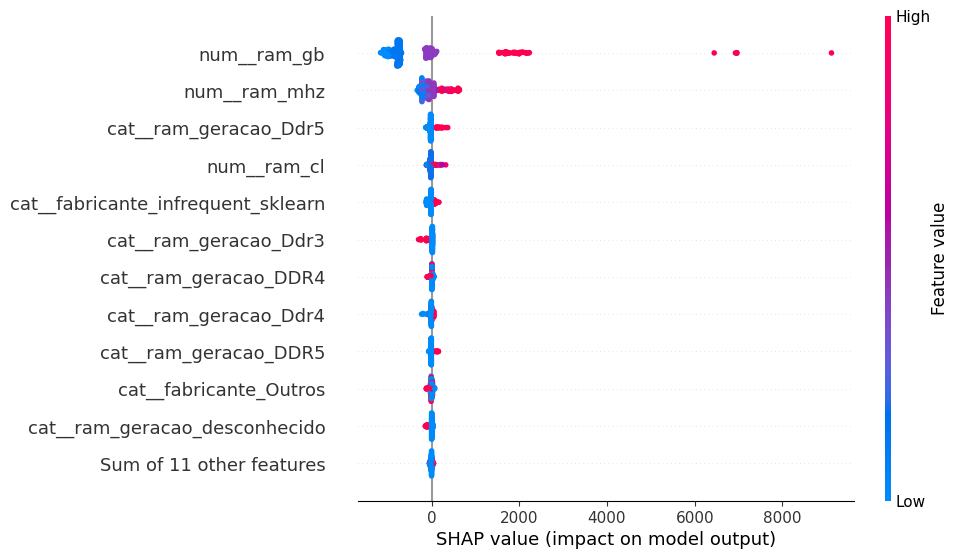

In [51]:
shap.plots.beeswarm(shap_values, max_display=12)

**Waterfall** — explica **um** produto: da média até o preço final, feature a
feature. Ótimo pro app mostrar *por que* aquele preço.

Memória RAM Kingston Fury Beast, 128GB (4x32GB), 5600MHz, DDR5, CL40,para Intel XMP, Preto - KF556C40BBK4-128
preço real: 13679.90 | previsto: 11163.22


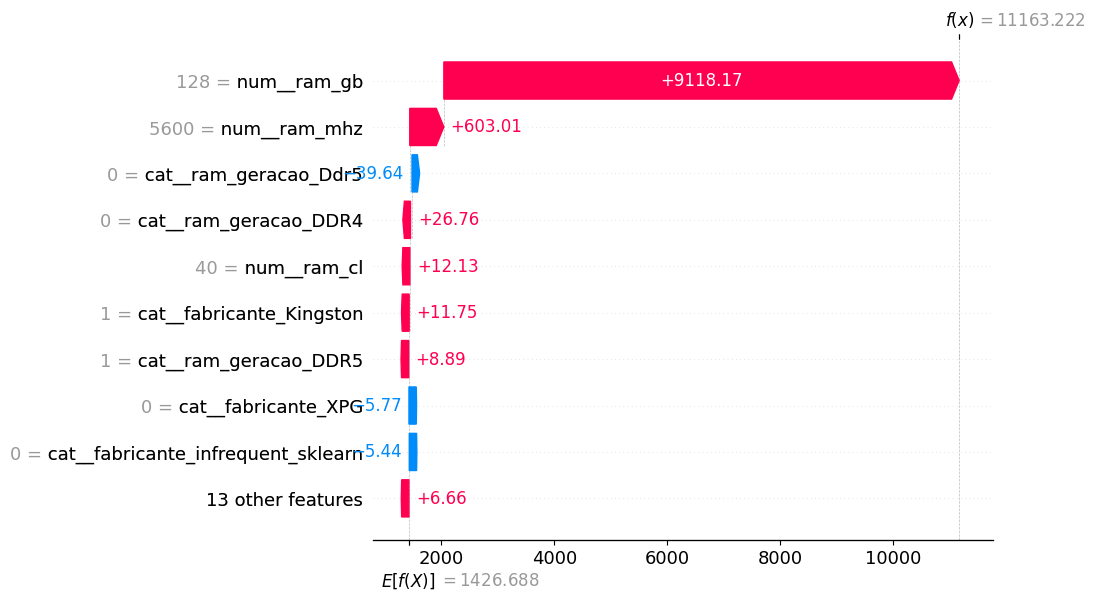

In [52]:
j = int(np.argmax(pred_teste))   # o mais caro previsto, por exemplo
if "nome" in d.columns:
    print(d.loc[X_teste.index[j], "nome"])
print(f"preço real: {y_teste[j]:.2f} | previsto: {pred_teste[j]:.2f}")
shap.plots.waterfall(shap_values[j])

**Scatter** — efeito de uma feature específica (aqui a capacidade). Mostra se o
efeito é linear, tem limiar, ou depende de outras variáveis (dispersão vertical).

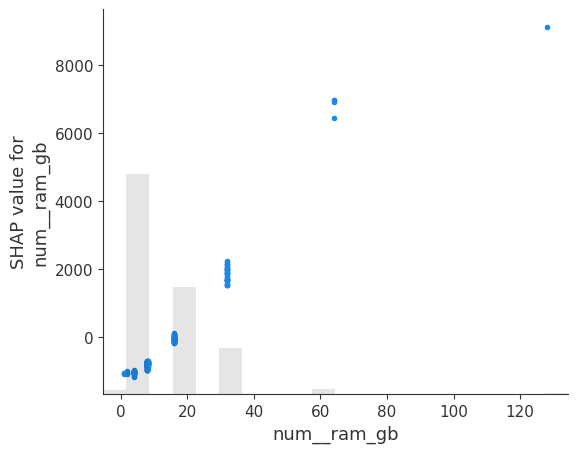

In [53]:
col_gb = [c for c in Xte.columns if c.endswith("ram_gb")]
if col_gb:
    shap.plots.scatter(shap_values[:, col_gb[0]])
else:
    print("coluna de capacidade não encontrada; ajuste o nome se necessário")

## Comparação com modelo fundacional (TabICL)

O TabICL prevê **sem tuning** e devolve **quantis** — uma faixa de 90% direto do
modelo (quantis 5% e 95%), sem calibração. Comparamos:

- **acurácia** (MAE) do TabICL out-of-the-box vs a RandomForest;
- **incerteza**: faixa nativa do TabICL vs RF + conformal normalizado.

A célula é opcional e protegida: se o `tabicl` não estiver instalado, ela apenas
avisa e segue. Para instalar: `pip install tabicl`.

In [31]:
pip install tabicl

   ---------------------------------------- 0.0/123.0 MB ? eta -:--:--
   -- ------------------------------------- 8.4/123.0 MB 39.8 MB/s eta 0:00:03
   ---- ----------------------------------- 15.2/123.0 MB 35.4 MB/s eta 0:00:04
   ------- -------------------------------- 22.5/123.0 MB 34.8 MB/s eta 0:00:03
   --------- ------------------------------ 30.7/123.0 MB 36.0 MB/s eta 0:00:03
   ------------ --------------------------- 39.1/123.0 MB 36.5 MB/s eta 0:00:03
   --------------- ------------------------ 47.2/123.0 MB 36.6 MB/s eta 0:00:03
   ----------------- ---------------------- 55.3/123.0 MB 36.7 MB/s eta 0:00:02
   -------------------- ------------------- 63.4/123.0 MB 37.1 MB/s eta 0:00:02
   ----------------------- ---------------- 71.6/123.0 MB 37.1 MB/s eta 0:00:02
   ------------------------- -------------- 79.7/123.0 MB 37.1 MB/s eta 0:00:02
   ---------------------------- ----------- 88.1/123.0 MB 37.2 MB/s eta 0:00:01
   ------------------------------- -------- 96.2/1


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [54]:
try:
    from tabicl import TabICLRegressor

    # TabICL recebe o contexto = treino + calibração (mesma info dos outros)
    X_ctx = np.vstack([Xtr.to_numpy(), Xca.to_numpy()])
    y_ctx = np.concatenate([y_treino, y_cal])

    reg = TabICLRegressor()
    reg.fit(X_ctx, y_ctx)

    saida = reg.predict(Xte.to_numpy(),
                        output_type=["mean", "quantiles"],
                        alphas=[0.05, 0.5, 0.95])
    pred_tabicl = saida["mean"]
    baixo_tab = saida["quantiles"][:, 0]
    alto_tab  = saida["quantiles"][:, 2]

    tab = pd.DataFrame([
        {"modelo": "RandomForest",           "MAE": mean_absolute_error(y_teste, pred_teste)},
        {"modelo": "TabICL (sem tuning)",     "MAE": mean_absolute_error(y_teste, pred_tabicl)},
    ])
    print(tab.to_string(index=False))

    inc = pd.DataFrame([
        resumo("RF + conformal norm.",   baixo_norm, alto_norm),
        resumo("TabICL quantis nativos", baixo_tab, alto_tab),
    ])
    display(inc)
except ModuleNotFoundError:
    print("tabicl não instalado — pulei esta comparação. (pip install tabicl)")

             modelo        MAE
       RandomForest 251.982884
TabICL (sem tuning) 220.343015


,metodo,cobertura,largura_media
0,RF + conformal norm.,0.926829,1306.672230
1,TabICL quantis nativos,0.930314,906.742126


## Salvando os artefatos para o app

Salvamos **tudo que o app precisa** num único `.joblib`: o pré-processador (para
transformar um produto novo), os dois modelos, o corte conformal `q_norm` e a
config de features. Também exportamos a tabela de resultados do teste, útil pros
slides e pra pré-calcular telas do app.

In [33]:
import os
os.makedirs(MODEL_DIR, exist_ok=True)

bundle = {
    "categoria": CATEGORIA,
    "alvo": ALVO,
    "alpha": alpha,
    "num": num,
    "cat": cat,
    "preproc": preproc,
    "modelo_media": modelo_media,
    "modelo_variancia": modelo_variancia,
    "q_norm": q_norm,
    "feature_nomes": list(feat_nomes),
    "metricas": {
        "mae": float(mean_absolute_error(y_teste, pred_teste)),
        "r2": float(r2_score(y_teste, pred_teste)),
        "cobertura": float(((y_teste >= baixo_norm) & (y_teste <= alto_norm)).mean()),
        "largura_media": float(np.mean(alto_norm - baixo_norm)),
    },
}
caminho = f"{MODEL_DIR}/modelo_preco_{CATEGORIA}.joblib"
joblib.dump(bundle, caminho)
res_teste.to_csv(f"{MODEL_DIR}/resultado_teste_{CATEGORIA}.csv", index=False)
print("salvo:", caminho)
print("métricas:", bundle["metricas"])

salvo: modelos/modelo_preco_ram.joblib
métricas: {'mae': 249.45486674653947, 'r2': 0.9158851621946202, 'cobertura': 0.9233449477351916, 'largura_media': 1304.9441512713033}


### Função de inferência (a mesma que o app vai usar)

Recebe as specs de um produto (um dicionário), aplica o pré-processador salvo e
devolve preço justo + faixa. No app, um passo anterior extrai essas specs do nome
via as regexes do notebook de NLP.

In [34]:
def prever_preco(specs: dict, bundle=bundle):
    X1 = pd.DataFrame([specs])
    for c in bundle["num"] + bundle["cat"]:
        if c not in X1.columns:
            X1[c] = np.nan
    X1 = X1[bundle["num"] + bundle["cat"]]
    Xt = pd.DataFrame(bundle["preproc"].transform(X1),
                      columns=bundle["preproc"].get_feature_names_out())
    p = float(bundle["modelo_media"].predict(Xt)[0])
    esc = float(np.sqrt(max(bundle["modelo_variancia"].predict(Xt)[0], 1e-6)))
    lo, hi = p - bundle["q_norm"] * esc, p + bundle["q_norm"] * esc
    return {"preco_justo": round(p, 2), "faixa": (round(lo, 2), round(hi, 2))}

# exemplo
prever_preco({"ram_gb": 16, "ram_mhz": 3200, "ram_cl": 16,
              "ram_geracao": "DDR4", "fabricante": "Kingston"})

{'preco_justo': 1263.15, 'faixa': (np.float64(814.12), np.float64(1712.18))}

In [35]:
print(d["ram_mhz"].describe())
print("MAE teste: R$", round(mean_absolute_error(y_teste, pred_teste), 2))

count     1079.000000
mean      3196.721038
std       2169.872029
min        200.000000
25%       2133.000000
50%       3200.000000
75%       3200.000000
max      56600.000000
Name: ram_mhz, dtype: float64
MAE teste: R$ 249.45


In [36]:
d.nlargest(5, "ram_mhz")[["nome", "ram_mhz", "data_coleta"]]


,nome,ram_mhz,data_coleta
9358,Memoria Hiksemi 16gb Ddr5 56600 Mhz 1.1v Deskt...,56600.0,2026-06-26
3757,Memoria Ram Kingston 8GB Ddr3 13333mhz Notebook,13333.0,2026-05-16
4206,Memória Ddr5 96gb 7000mhz Corsair Vengeance RG...,7000.0,2026-05-16
3918,"Mem?ria Kingston Fury Beast, RGB, 16gb, 6800mh...",6800.0,2026-05-16
4140,"Memória RAM Corsair Dominator Titanium, RGB, 3...",6600.0,2026-05-16


## Próximos passos

- **Generalizar**: rodar este notebook para as outras 5 categorias (só mudar
  `CATEGORIA`), gerando um `.joblib` por categoria.
- **Recomendador v2**: trocar o score à mão pelo `desvio_pct` (distância do preço
  justo) no ranking dos dois modos.
- **App (Streamlit)**: carregar os `.joblib`, oferecer as três telas — build por
  orçamento, peças compatíveis, e *analisar um produto* (cola nome + preço → veredito
  barato/justo/caro + waterfall SHAP).